In [1]:
#
# You can copy this entire code block into a single cell in your Jupyter Notebook.
#

import numpy as np
import matplotlib.pyplot as plt

# =================================================================================
#  FUNCTION 1: For creating a simple, single pulse sequence
# =================================================================================
def create_simple_sequence(pulse_sequence_steps, channel_mapping):
    """
    Processes a user-defined sequence and returns the low-level data and total period.
    This is ideal for creating a single, fixed sequence.

    Args:
        pulse_sequence_steps (list): A list of dictionaries defining the pulse sequence.
        channel_mapping (dict): A map of channel names to physical channel numbers.

    Returns:
        tuple: (low_level_sequence, total_period_us)
    """
    print("--- Creating simple sequence ---")
    total_period_us = sum(step['duration_us'] for step in pulse_sequence_steps)
    
    low_level_sequence = []
    for step in pulse_sequence_steps:
        duration_ns = int(step['duration_us'] * 1000)
        # Safely get channel list, defaulting to empty if not provided
        channel_names_on = step.get('channels_on', [])
        high_channels = [channel_mapping.get(name) for name in channel_names_on]
        
        if duration_ns > 0:
            low_level_sequence.append((duration_ns, high_channels, 0.0, 0.0))
            
    print(f"Total sequence duration: {total_period_us:.2f} µs")
    return low_level_sequence, total_period_us

# =================================================================================
#  FUNCTION 2: For creating a continuous sweep sequence
# =================================================================================
def create_sweep_sequence(sweep_params, subsequence_generator, channel_mapping):
    """
    Generates one single, continuous sequence for a sweep experiment.

    Args:
        sweep_params (dict): A dictionary with 'start', 'end', and 'steps' for the sweep.
        subsequence_generator (function): A function that takes a sweep value
                                          and returns the pulse steps for one sub-sequence.
        channel_mapping (dict): A map of channel names to physical channel numbers.

    Returns:
        tuple: (full_low_level_sequence, total_duration_us)
    """
    print(f"--- Creating sweep sequence with {sweep_params['steps']} steps ---")
    sweep_values = np.linspace(sweep_params['start'], sweep_params['end'], sweep_params['steps'])
    
    full_sequence_data = []
    
    for value in sweep_values:
        # 1. Generate the sub-sequence for the current sweep value
        sub_sequence_steps = subsequence_generator(value)
        
        # 2. Convert the sub-sequence to low-level format and append it
        for step in sub_sequence_steps:
            duration_ns = int(step['duration_us'] * 1000)
            channel_names_on = step.get('channels_on', [])
            high_channels = [channel_mapping.get(name) for name in channel_names_on]
            
            if duration_ns > 0:
                full_sequence_data.append((duration_ns, high_channels, 0.0, 0.0))

    total_duration_ns = sum(p[0] for p in full_sequence_data)
    total_duration_us = total_duration_ns / 1000.0
    
    print(f"Total continuous sequence duration: {total_duration_us:.2f} µs")
    return full_sequence_data, total_duration_us


# =================================================================================
#  PLOTTING FUNCTION (Adapted to plot a portion of a long sequence)
# =================================================================================
def plot_sequence(low_level_sequence, channel_mapping, plot_duration_us=None, title='Pulse Sequence'):
    """
    Generates a plot for a low-level pulse sequence. Can plot a partial duration.
    """
    plot_data = low_level_sequence
    
    # If a plot duration is specified, truncate the data for plotting
    if plot_duration_us is not None:
        plot_duration_ns = plot_duration_us * 1000
        plot_data = []
        current_time_ns = 0
        for pulse in low_level_sequence:
            plot_data.append(pulse)
            current_time_ns += pulse[0]
            if current_time_ns >= plot_duration_ns:
                break
    
    print(f"--- Generating Plot: {title} ---")
    fig, ax = plt.subplots(figsize=(15, 6))
    channel_names = {v: k for k, v in channel_mapping.items()}
    active_channels = sorted(list(channel_mapping.values()))

    for chan_num in active_channels:
        x_coords, y_coords = [0], [0]
        current_time_ns = 0
        for duration_ns, high_channels, _, _ in plot_data:
            level = 1 if chan_num in high_channels else 0
            if y_coords[-1] != level:
                x_coords.append(current_time_ns)
                y_coords.append(level)
            current_time_ns += duration_ns
            x_coords.append(current_time_ns)
            y_coords.append(level)
        
        time_us = np.array(x_coords) / 1000.0
        waveform = np.array(y_coords) * 0.8 + (chan_num - 1)
        ax.plot(time_us, waveform, label=channel_names.get(chan_num, f'CH {chan_num}'))

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Time (µs)', fontsize=12)
    ax.set_ylabel('Digital Channel', fontsize=12)
    ax.set_yticks([ch - 1 for ch in active_channels])
    ax.set_yticklabels([channel_names.get(ch, f'CH {ch}') for ch in active_channels])
    ax.set_ylim(-0.5, 8)
    ax.grid(axis='y', linestyle=':')
    ax.legend()
    plt.show()

In [2]:
# --- Define hardware channels ---
channel_map = {
    'Rabi_Pulse': 1,
    'Trigger': 5,
}

--- Creating simple sequence ---
Total sequence duration: 450.00 µs
--- Generating Plot: My Fixed Sequence ---


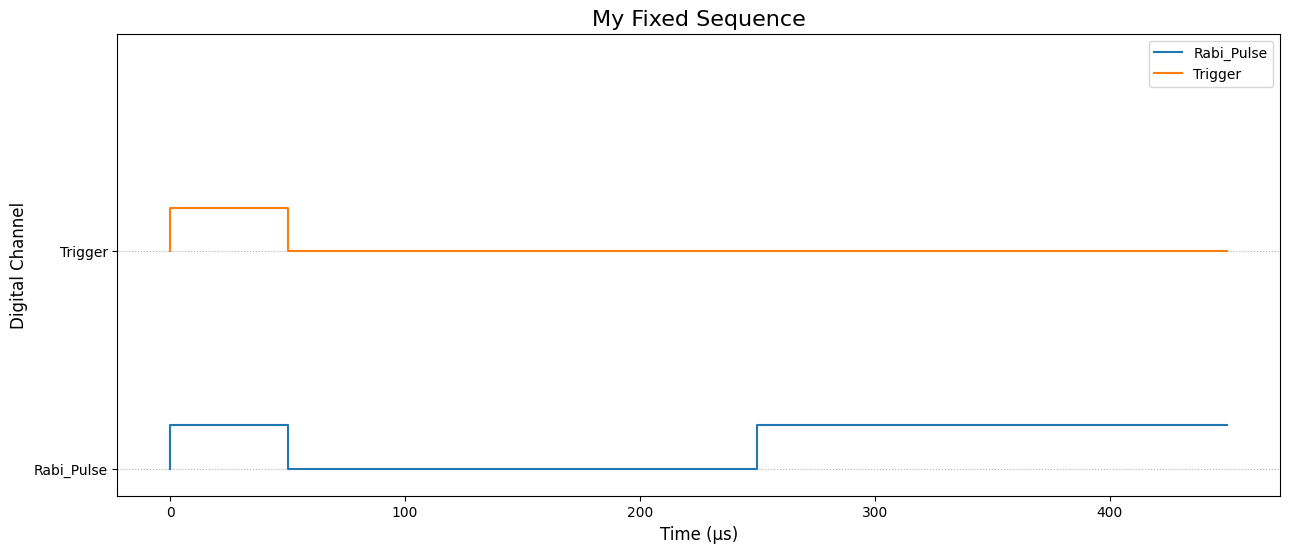

In [3]:
# Define the steps for a single, fixed sequence
my_fixed_steps = [
    {'duration_us': 50, 'channels_on': ['Rabi_Pulse', 'Trigger']},
    {'duration_us': 200, 'channels_on': []},
    {'duration_us': 200, 'channels_on': ['Rabi_Pulse']},
]

# Create and plot the simple sequence
simple_data, simple_period = create_simple_sequence(my_fixed_steps, channel_map)
plot_sequence(simple_data, channel_map, title="My Fixed Sequence")

--- Creating sweep sequence with 5 steps ---
Total continuous sequence duration: 310.00 µs
--- Generating Plot: Rabi Sweep Sequence (First 3 Steps) ---


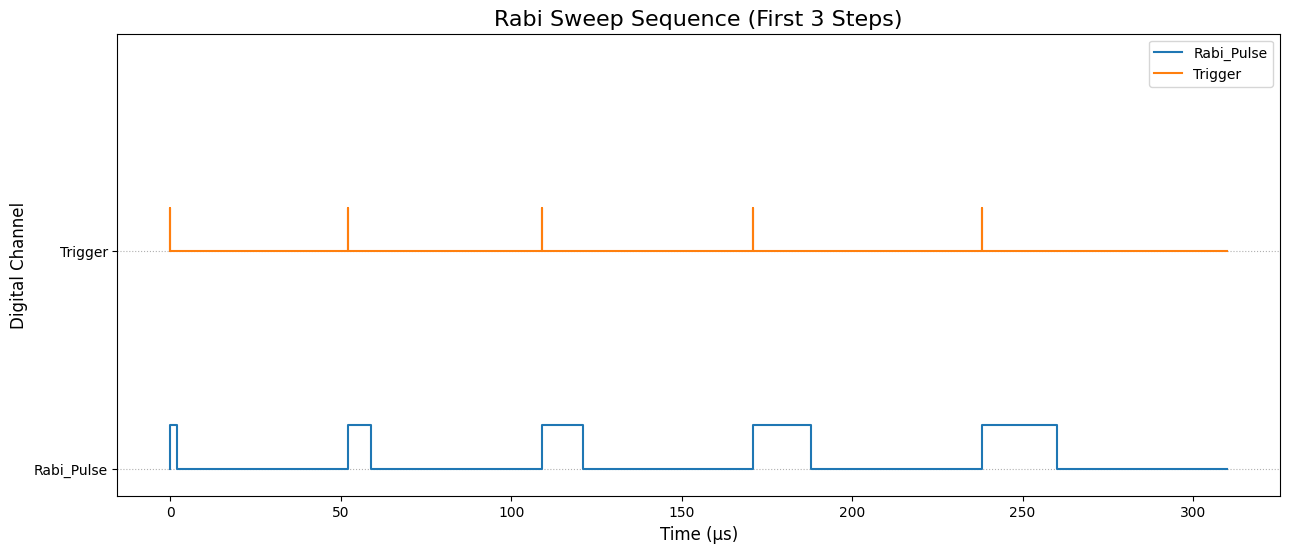

In [5]:
# --- 1. Define Sweep Parameters ---
rabi_sweep_params = {
    'start': 2,    # Start sweep with a 2 µs Rabi pulse
    'end': 22,     # End with a 22 µs pulse
    'steps': 5,    # Perform 5 steps in the sweep
}

# Fixed wait time after each Rabi pulse
WAIT_TIME_US = 50
# Fixed duration for the trigger that starts each step
TRIGGER_DURATION_US = 0.05 # 50 ns

# --- 2. Define the Sub-Sequence Generator ---
# This function defines the structure of ONE step in the sweep.
# It takes the current Rabi pulse duration as input.
def rabi_subsequence_generator(rabi_duration_us):
    
    pulse_after_trigger_us = rabi_duration_us - TRIGGER_DURATION_US
    if pulse_after_trigger_us < 0:
        pulse_after_trigger_us = 0
    
    # This list of dictionaries is the "recipe" for one step
    sub_sequence = [
        # Part 1: Trigger and Rabi Pulse ON
        {'duration_us': TRIGGER_DURATION_US, 'channels_on': ['Rabi_Pulse', 'Trigger']},
        # Part 2: Rabi Pulse continues alone
        {'duration_us': pulse_after_trigger_us, 'channels_on': ['Rabi_Pulse']},
        # Part 3: Wait time for measurement
        {'duration_us': WAIT_TIME_US, 'channels_on': []}
    ]
    return sub_sequence

# --- 3. Create the full, continuous sweep sequence ---
full_rabi_sequence, total_rabi_duration = create_sweep_sequence(
    rabi_sweep_params,
    rabi_subsequence_generator,
    channel_map
)

# --- 4. Plot the first few steps for verification ---
# We calculate the duration of the first 3 steps to set a sensible plot window
one_step_approx_duration = rabi_sweep_params['start'] + WAIT_TIME_US
plot_window = one_step_approx_duration *10

plot_sequence(
    full_rabi_sequence,
    channel_map,
    plot_duration_us=plot_window,
    title="Rabi Sweep Sequence (First 3 Steps)"
)

Generating 50 sequence steps...


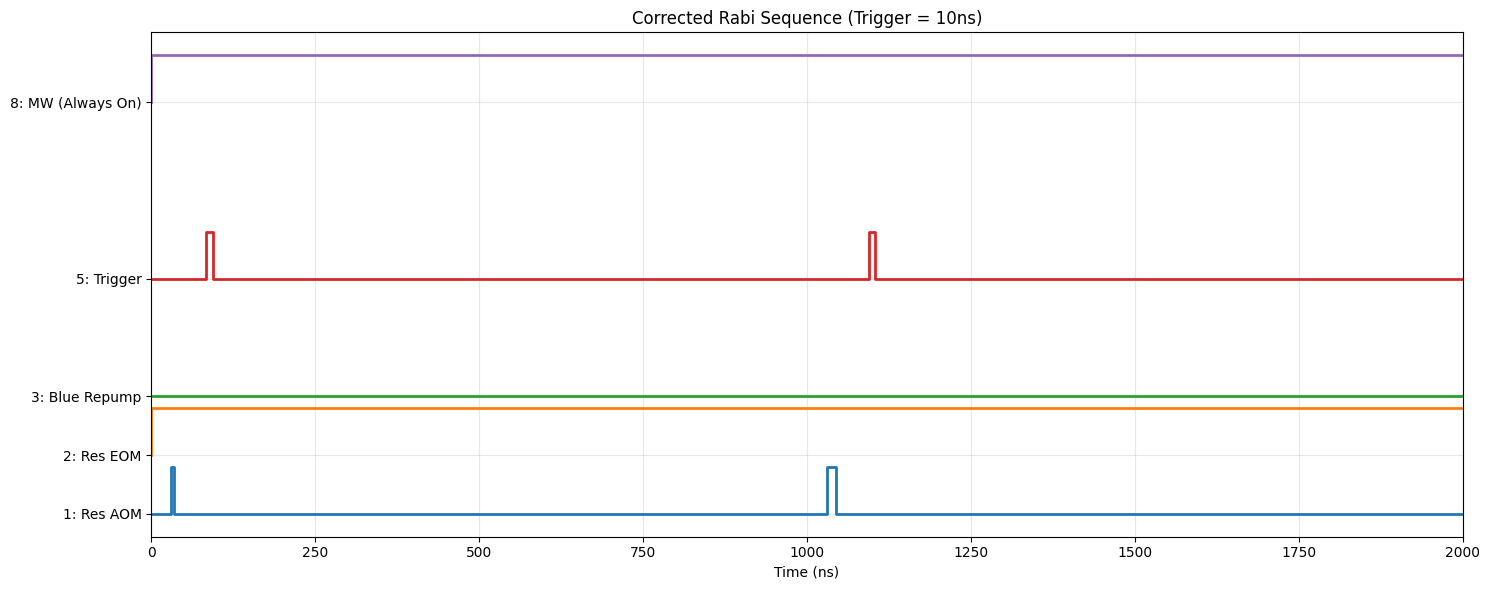

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. HARDWARE CONFIGURATION
# ==============================================================================
CH_RES_AOM   = 1 - 1  # Digital Ch 1
CH_RES_EOM   = 2 - 1  # Digital Ch 2
CH_BLUE      = 3 - 1  # Digital Ch 3
CH_TRIGGER   = 5 - 1  # Digital Ch 5
CH_MW        = 8 - 1  # Digital Ch 8

SEQ_TOTAL_NS = 1000  # Total length of one sequence step

# ==============================================================================
# 2. HELPER: Bitmask Generator
# ==============================================================================
def get_state(channels_on_list):
    state = 0
    state |= (1 << CH_MW) # Always keep MW on
    for ch in channels_on_list:
        state |= (1 << ch)
    return state

# ==============================================================================
# 3. SEQUENCE GENERATOR
# ==============================================================================
def create_rabi_sweep():
    sequence_stream = []
    # Define Analog Voltages (Set to 0.0V if not used)
    A0 = 0.055
    A1 = 0.15
    # Sweep Parameters: 4ns to 500ns
    drive_lengths = np.linspace(4, 500, 50).astype(int) 

    print(f"Generating {len(drive_lengths)} sequence steps...")

    for t_drive in drive_lengths:
        # --- TIMING CALCULATIONS ---
        t_blue  = 0
        t_wait1 = 0
        t_init  = 0
        t_wait2 = 30
        # t_drive is variable
        t_wait3 = 50
        t_wait4 = 100 
        
        # Calculate total Readout Time available
        used_time = t_blue + t_wait1 + t_init + t_wait2 + t_drive + t_wait3 + t_wait4
        total_readout_time = SEQ_TOTAL_NS - used_time
        
        # Split Readout into Trigger (10ns) and Tail (Remainder)
        t_trig_pulse = 10
        t_readout_tail = total_readout_time - t_trig_pulse
        
        if t_readout_tail < 0:
            print(f"Warning: Sequence too long. Readout clipped.")
            t_readout_tail = 0

        # --- PULSE CONSTRUCTION ---
        
        # 1. Blue Repump
        sequence_stream.append((t_blue, get_state([CH_RES_EOM])))

        # 2. Wait
        sequence_stream.append((t_wait1, get_state([CH_RES_EOM])))

        # 3. Initialization
        sequence_stream.append((t_init, get_state([CH_RES_EOM])))

        # 4. Wait
        sequence_stream.append((t_wait2, get_state([CH_RES_EOM])))

        # 5. Drive (Raman)
        sequence_stream.append((t_drive, get_state([CH_RES_AOM, CH_RES_EOM])))

        # 6. Wait
        sequence_stream.append((t_wait3, get_state([CH_RES_EOM])))

        # 7. Readout PART A: AOM + Trigger (10 ns)
        sequence_stream.append((t_trig_pulse, get_state([CH_RES_EOM, CH_TRIGGER])))

        # 8. Readout PART B: AOM Only (Remainder)
        sequence_stream.append((t_readout_tail, get_state([CH_RES_EOM])))

        # 9. End Wait
        sequence_stream.append((t_wait4, get_state([CH_RES_EOM])))

    return sequence_stream

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
def plot_pulsestreamer_sequence(sequence_data, max_time_ns=6000):
    fig, ax = plt.subplots(figsize=(15, 6))
    
    labels = {
        CH_RES_AOM: "1: Res AOM",
        CH_RES_EOM: "2: Res EOM",
        CH_BLUE:    "3: Blue Repump",
        CH_TRIGGER: "5: Trigger",
        CH_MW:      "8: MW (Always On)"
    }
    
    active_bits = sorted(labels.keys())
    
    # Plotting Logic
    for bit in active_bits:
        x_vals = [0]
        y_vals = [0]
        t = 0
        for duration, state in sequence_data:
            level = 1 if (state & (1 << bit)) else 0
            x_vals.extend([t, t])
            y_vals.extend([y_vals[-1], level])
            t += duration
            if t > max_time_ns: break
        
        y_stacked = np.array(y_vals) * 0.8 + bit
        ax.plot(x_vals, y_stacked, label=labels[bit], linewidth=2)
        
    ax.set_yticks(active_bits)
    ax.set_yticklabels([labels[b] for b in active_bits])
    ax.set_xlabel("Time (ns)")
    ax.set_title(f"Corrected Rabi Sequence (Trigger = 10ns)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max_time_ns)
    plt.tight_layout()
    plt.show()

# Run
seq_data = create_rabi_sweep()
plot_pulsestreamer_sequence(seq_data, max_time_ns=2000)

In [38]:
seq_data

[(0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (30, 130, 0.055, 0.15), (4, 131, 0.055, 0.15), (50, 130, 0.055, 0.15), (10, 146, 0.055, 0.15), (806, 130, 0.055, 0.15), (100, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (30, 130, 0.055, 0.15), (14, 131, 0.055, 0.15), (50, 130, 0.055, 0.15), (10, 146, 0.055, 0.15), (796, 130, 0.055, 0.15), (100, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (30, 130, 0.055, 0.15), (24, 131, 0.055, 0.15), (50, 130, 0.055, 0.15), (10, 146, 0.055, 0.15), (786, 130, 0.055, 0.15), (100, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (30, 130, 0.055, 0.15), (34, 131, 0.055, 0.15), (50, 130, 0.055, 0.15), (10, 146, 0.055, 0.15), (776, 130, 0.055, 0.15), (100, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (0, 130, 0.055, 0.15), (30, 130, 0.055, 0.15), (44, 131, 0.055, 0.15), (50, 130, 0.055, 0.15),

In [37]:
print("Uploading sequence with trigger and repump to the Pulse Streamer...")

pulsestreamer.upload_sequence(seq_data)

print("Starting the pulse sequence...")

pulsestreamer.ps.stream(pulsestreamer.sequence_data, n_runs=-1)

Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...


struct.error: required argument is not an integer

========= Remote Traceback (1) =========
Traceback (most recent call last):
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 369, in _dispatch_request
    res = self._HANDLERS[handler](self, *args)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 863, in _handle_call
    return obj(*args, **dict(kwargs))
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\pulsestreamer\jrpc\pulse_streamer_jrpc.py", line 117, in stream
    self.__stream_binary(seq, n_runs, final)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\pulsestreamer\jrpc\pulse_streamer_jrpc.py", line 177, in __stream_binary
    s.sendall(struct.pack(fmt, *s_enc))
struct.error: required argument is not an integer


Generating data for 50 steps...
56726


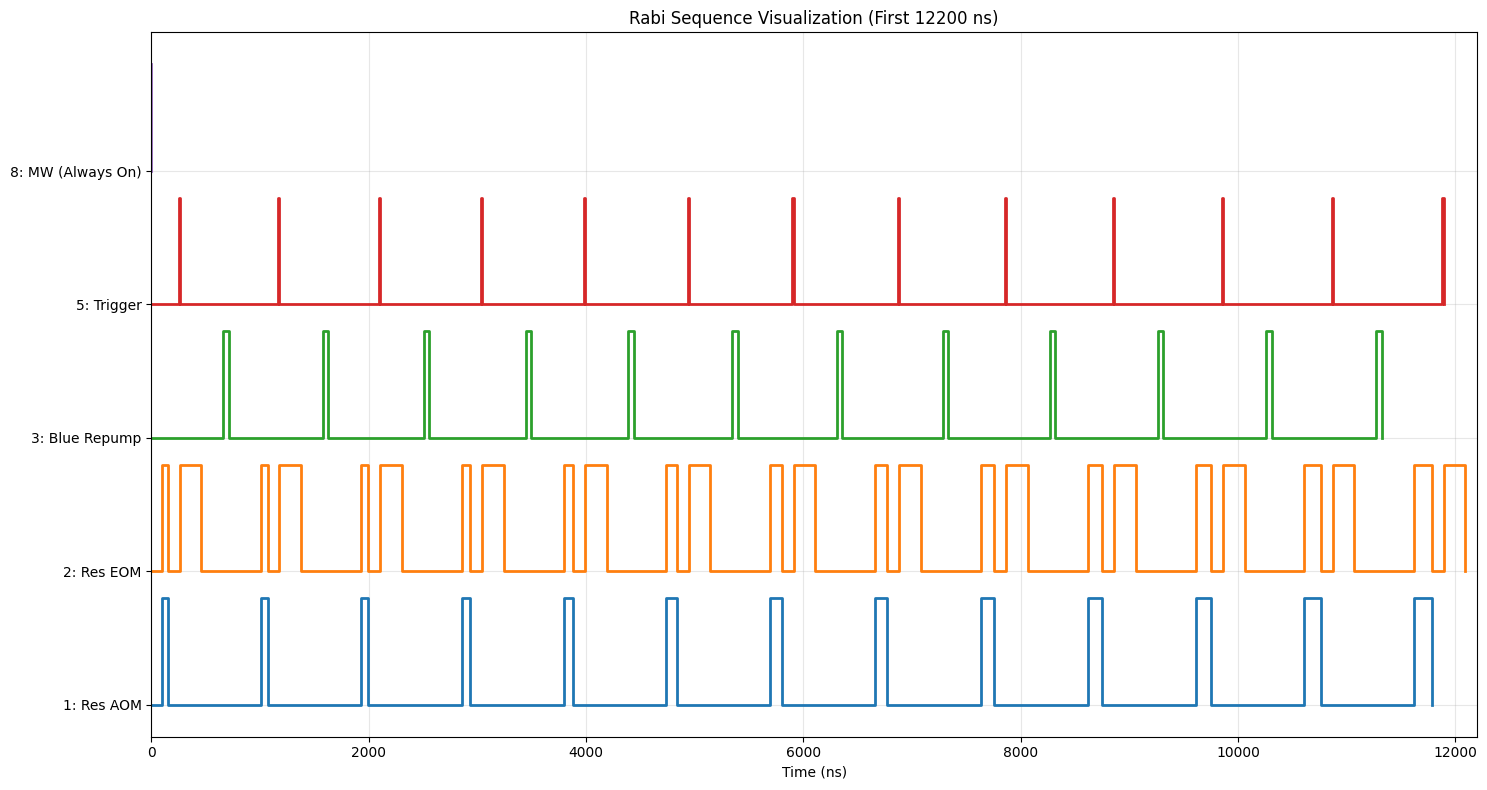

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pulsestreamer import Sequence

# ==============================================================================
# 1. HARDWARE MAPPING
# ==============================================================================
CH_RES_AOM   = 1 - 1
CH_RES_EOM   = 2 - 1
CH_BLUE      = 3 - 1
CH_TRIGGER   = 6 - 1
CH_MW        = 8 - 1
SEQ_TOTAL_NS = 1000

# ==============================================================================
# 2. DATA GENERATOR (Returns Python Dictionary, not Swabian Object)
# ==============================================================================
def generate_rabi_data():
    """
    Generates the raw timing data (digital trains) for the Rabi sequence.
    Returns:
        digital_trains (dict): {channel_idx: [(duratiaon, level), ...]}
        analog_settings (dict): {channel_idx: [(duration, voltage), ...]}
    """
    # Sweep Parameters
    drive_lengths = np.linspace(50, 500, 50).astype(int) 
    
    # Initialize dictionary for channels 0-7
    digital_trains = {ch: [] for ch in range(8)}
    
    print(f"Generating data for {len(drive_lengths)} steps...")

    for t_drive_val in drive_lengths:
        t_drive = int(t_drive_val)
        
        # --- TIMING ---
        t_blue   = 0    
        t_wait1  = 100    
        t_init   = 0   
        t_wait2  = 100
        t_wait3  = 0
        t_wait4  = 200
        
        used_time = t_blue + t_wait1 + t_init + t_wait2 + int(max(drive_lengths)) + t_wait3 + t_wait4
        total_readout = int(SEQ_TOTAL_NS - used_time)
        
        t_trig  = 10
        t_tail  = int(total_readout - t_trig)
        t_read =  200
        t_init = t_tail - t_read
        if t_tail < 0: t_tail = 0 

        # --- STEP DEFINITIONS ---
        step_definitions = [
            #(t_blue,  [CH_BLUE, CH_MW]),                
            (t_wait1, [CH_MW]),                         
            #(t_init,  [CH_RES_EOM, CH_MW]),            
            # (t_wait2, [CH_MW]),                         
           (t_drive, [CH_RES_AOM, CH_RES_EOM, CH_MW]), 
           (t_wait2, [CH_MW]),
           (t_trig,  [CH_TRIGGER, CH_MW]), 
            (t_read,  [CH_MW, CH_RES_EOM]),   #CH_RES_EOM     
            (t_wait2, [CH_MW]), 
            
            (t_wait2, [CH_MW]),
            (t_init,  [CH_MW, CH_RES_AOM]),    
            (t_blue,  [CH_BLUE, CH_MW]),
            (t_wait4, [CH_MW])                          
        ]

        # --- BUILD TRAINS ---
        for duration, active_chs in step_definitions:
            if duration <= 0: continue 
            
            for ch_idx in range(8):
                level = 1 if ch_idx in active_chs else 0
                
                # Merge identical adjacent pulses to save memory
                if digital_trains[ch_idx] and digital_trains[ch_idx][-1][1] == level:
                    prev_dur, prev_lvl = digital_trains[ch_idx].pop()
                    digital_trains[ch_idx].append( (prev_dur + duration, prev_lvl) )
                else:
                    digital_trains[ch_idx].append( (duration, level) )

    # --- ANALOG SETTINGS ---
    # Constant voltages for the whole experiment duration
    total_duration_ns = sum(d for d, _ in digital_trains[0])
    analog_settings = {
        0: [(total_duration_ns, 0.2)],
        1: [(total_duration_ns, 0.4)]
    }
    print(total_duration_ns)
    return digital_trains, analog_settings

# ==============================================================================
# 3. CONVERTER (Dict -> Swabian Sequence Object)
# ==============================================================================
def create_sequence_object(digital_trains, analog_settings):
    seq = Sequence()
    
    # Set Digital
    for ch, train in digital_trains.items():
        if train:
            seq.setDigital(ch, train)
            
    # Set Analog
    for ch, train in analog_settings.items():
        if train:
            seq.setAnalog(ch, train)
            
    return seq

# ==============================================================================
# 4. PLOTTER (Visualizes the Data)
# ==============================================================================
def plot_sequence_data(digital_trains, max_time_ns=6000):
    fig, ax = plt.subplots(figsize=(15, 8))
    
    labels = {
        CH_RES_AOM: "1: Res AOM",
        CH_RES_EOM: "2: Res EOM",
        CH_BLUE:    "3: Blue Repump",
        CH_TRIGGER: "5: Trigger",
        CH_MW:      "8: MW (Always On)"
    }
    
    # Filter only channels we care about or are active
    active_bits = sorted(list(labels.keys()))
    
    for i, bit in enumerate(active_bits):
        train = digital_trains.get(bit, [])
        
        x_vals = [0]
        y_vals = [0]
        t = 0
        
        for duration, level in train:
            # Add start of pulse
            x_vals.append(t)
            y_vals.append(y_vals[-1])
            
            # Step change
            x_vals.append(t)
            y_vals.append(level)
            
            t += duration
            if t > max_time_ns: break
            
        # Offset y-values for stacking
        # i is simply the index for plotting order (0, 1, 2...)
        y_stacked = np.array(y_vals) * 0.8 + i 
        
        ax.plot(x_vals, y_stacked, label=labels[bit], linewidth=2)

    ax.set_yticks(range(len(active_bits)))
    ax.set_yticklabels([labels[b] for b in active_bits])
    ax.set_xlabel("Time (ns)")
    ax.set_title(f"Rabi Sequence Visualization (First {max_time_ns} ns)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max_time_ns)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 5. EXECUTION
# ==============================================================================

# A. Generate Data
raw_dig, raw_ana = generate_rabi_data()
# B. Plot It (Verify logic before upload)
plot_sequence_data(raw_dig, max_time_ns=12200)



In [222]:

# C. Create Object
seq_obj = create_sequence_object(raw_dig, raw_ana)
print("Sequence object created.")

# D. Stream
print("Streaming to hardware...")
pulsestreamer.ps.stream(seq_obj, n_runs=-1)

Sequence object created.
Streaming to hardware...


In [162]:
total_duration_ns

NameError: name 'total_duration_ns' is not defined

In [112]:

seq_obj = create_rabi_sequence_object()
print("Sequence object created successfully.")

print("Uploading and streaming...")
pulsestreamer.ps.stream(seq_obj, n_runs=-1)

Generating Sequence with 50 steps...
Sequence object created successfully.
Uploading and streaming...
